# OLAH — Recipe Recommender: Training & EDA Notebook
**Coding Camp 2026 | CC26-PSU127 | AI Engineer**

Notebook ini mencakup:
1. Exploratory Data Analysis (EDA) dataset resep
2. Training model BERT-inspired dengan TensorFlow
3. Evaluasi performa model
4. Visualisasi embedding dengan TensorBoard
5. Demo inference

In [1]:
# Install dependencies
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn fastapi uvicorn google-generativeai

## 1. Import & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import sys

sys.path.append('../model')
from recipe_recommender import (
    DataPreprocessor, build_olah_model, OlahTrainer,
    RecipeEmbeddingEngine, BestModelCallback, CONFIG
)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2ECC71', '#3498DB', '#E74C3C', '#F39C12', '#9B59B6', '#1ABC9C', '#E67E22', '#34495E']
sns.set_palette(COLORS)

I0000 00:00:1778940736.611658   18031 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778940736.678707   18031 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778940739.349366   18031 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0
GPU available: False


E0000 00:00:1778940740.090053   18031 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Load & EDA Dataset

In [3]:
DATA_PATH = '../data/Recipes_Clean_Sampled.csv'
df = pd.read_csv(DATA_PATH, encoding='latin-1')

print(f'Shape: {df.shape}')
print(f'\nKolom: {list(df.columns)}')
print(f'\nSample data:')
df.head(3)

Shape: (1093, 11)

Kolom: ['recipe_name', 'ingredients_raw', 'steps', 'love_count', 'url', 'category', 'total_ingredients', 'ingredients_cleaned', 'total_steps', 'ingredients_clean', 'steps_clean']

Sample data:


,recipe_name,ingredients_raw,steps,love_count,url,category,total_ingredients,ingredients_cleaned,total_steps,ingredients_clean,steps_clean
0,abon sapi,450 gr daging sapi--400 ml santan kekentalan s...,"1) rebus daging bersama serai, daun salam, dan...",82,https://cookpad. com/id/resep/3758046-abon-sap...,sapi,14,"daging sapi, santan kekentalan, serai, daun sa...",4,"['450 gr daging sapi', '400 ml santan kekental...","['rebus daging bersama serai, daun salam, dan ..."
1,abon ikan tongkol,800 gr ikan tongkol--1 buah jeruk nipis--3 sdm...,1) lumuri ikan tongkol dengan air jeruk nipis ...,29,https://cookpad.com/id/resep/3491231-abon-ikan...,ikan,18,"ikan tongkol, jeruk nipis, bawang merah goreng...",4,"['800 gr ikan tongkol', '1 buah jeruk nipis', ...",['lumuri ikan tongkol dengan air jeruk nipis d...
2,asam manis sapi,"1 ons sapi, dipotong2 memanjang--1 buah wortel...","1) cuci bersih daging, kemudian potong2 memanj...",22,https://cookpad.com/id/resep/3601587-asam-mani...,sapi,17,"sapi, dipotong memanjang, wortel, dipotong, ca...",8,"['1 ons sapi, dipotong2 memanjang', '1 buah wo...","['cuci bersih daging, kemudian potong2 memanja..."


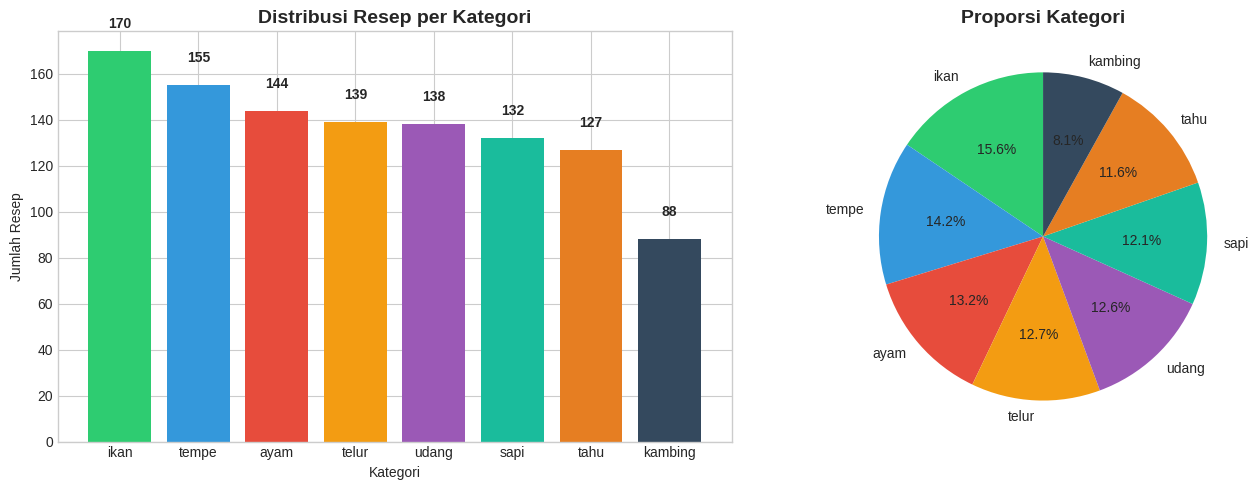

category
ikan       170
tempe      155
ayam       144
telur      139
udang      138
sapi       132
tahu       127
kambing     88
Name: count, dtype: int64


In [4]:
# Distribusi kategori
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df['category'].value_counts()

# Bar chart
axes[0].bar(cat_counts.index, cat_counts.values, color=COLORS)
axes[0].set_title('Distribusi Resep per Kategori', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Resep')
for i, (cat, cnt) in enumerate(cat_counts.items()):
    axes[0].text(i, cnt + 10, str(cnt), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(cat_counts.values, labels=cat_counts.index, colors=COLORS,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Kategori', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../saved_model/eda_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(cat_counts)

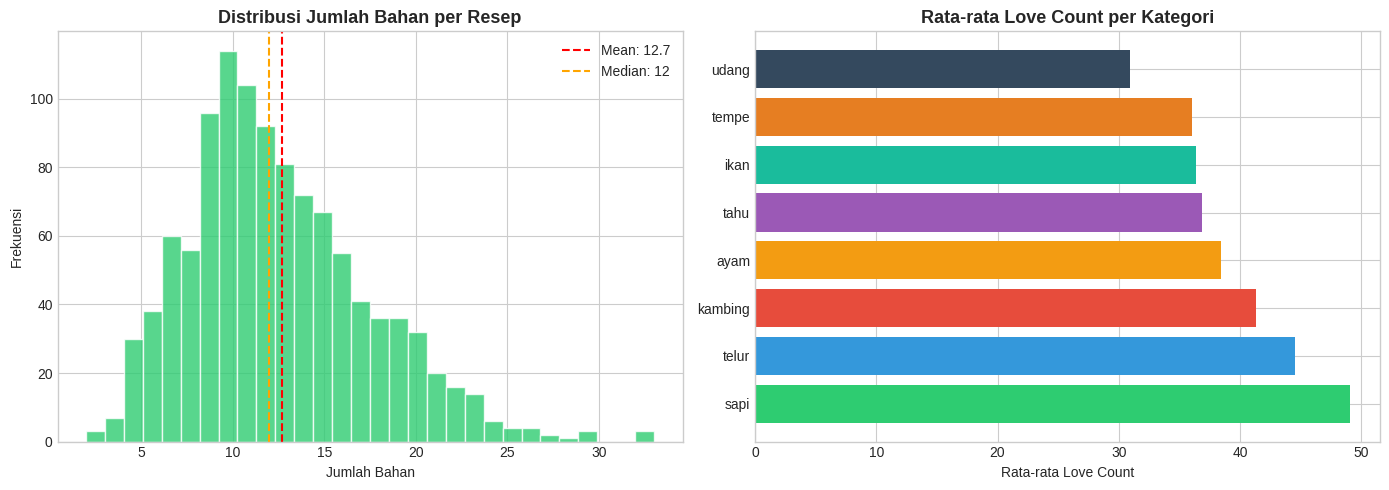

In [5]:
# Distribusi jumlah bahan per resep
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_ingredients'], bins=30, color='#2ECC71', edgecolor='white', alpha=0.8)
axes[0].axvline(df['total_ingredients'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["total_ingredients"].mean():.1f}')
axes[0].axvline(df['total_ingredients'].median(), color='orange', linestyle='--',
                label=f'Median: {df["total_ingredients"].median():.0f}')
axes[0].set_title('Distribusi Jumlah Bahan per Resep', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Bahan')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Love count per kategori
love_by_cat = df.groupby('category')['love_count'].mean().sort_values(ascending=False)
axes[1].barh(love_by_cat.index, love_by_cat.values, color=COLORS)
axes[1].set_title('Rata-rata Love Count per Kategori', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rata-rata Love Count')

plt.tight_layout()
plt.savefig('../saved_model/eda_ingredients_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

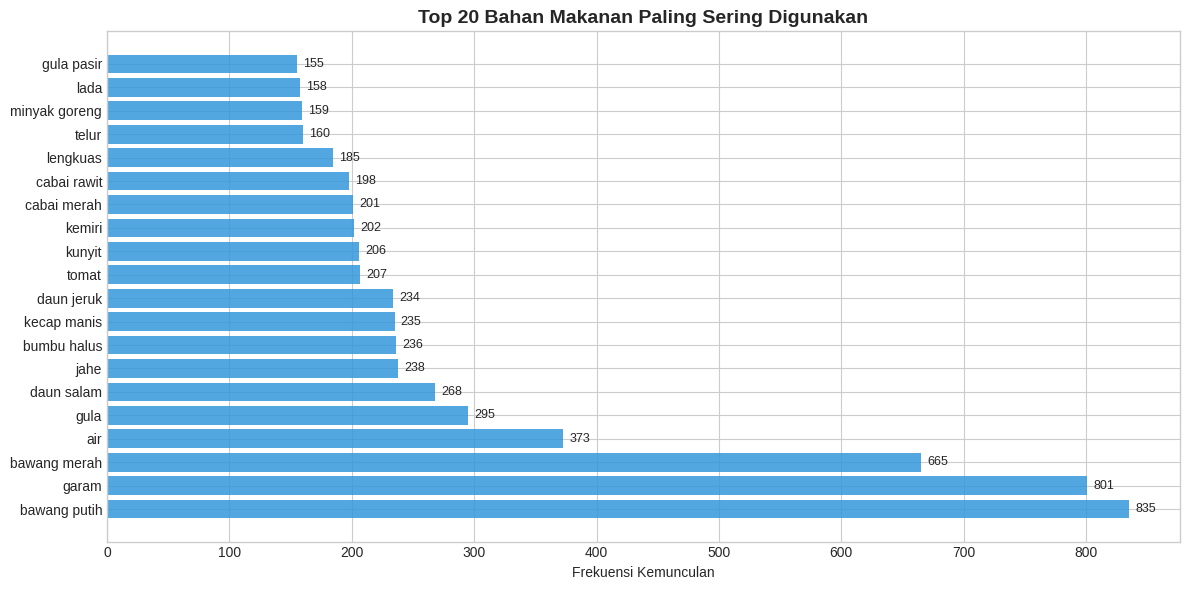

In [6]:
# Top bahan yang paling sering muncul
from collections import Counter

all_ingredients = []
for row in df['ingredients_cleaned'].dropna():
    for ing in str(row).split(','):
        clean = ing.strip().lower()
        if len(clean) > 2:
            all_ingredients.append(clean)

top_ingredients = Counter(all_ingredients).most_common(20)
names, counts = zip(*top_ingredients)

plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(names)), counts, color='#3498DB', alpha=0.85)
plt.yticks(range(len(names)), names)
plt.xlabel('Frekuensi Kemunculan')
plt.title('Top 20 Bahan Makanan Paling Sering Digunakan', fontsize=14, fontweight='bold')
for bar, count in zip(bars, counts):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../saved_model/eda_top_ingredients.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing & Training

In [7]:
from sklearn.model_selection import train_test_split

# Update CONFIG path
CONFIG['data_path'] = DATA_PATH

preprocessor = DataPreprocessor(CONFIG)
df_clean = preprocessor.load_and_prepare(DATA_PATH)

X = np.array(df_clean['ingredient_seq'].tolist(), dtype=np.int32)
y = df_clean['category_encoded'].values.astype(np.int32)

print(f'X shape: {X.shape}')
print(f'y distribution: {dict(zip(*np.unique(y, return_counts=True)))}')

[DATA] Loaded 1093 recipes dari ../data/Recipes_Clean_Sampled.csv
[DATA] After cleaning: 1093 recipes
[DATA] Categories: ['ayam', 'ikan', 'kambing', 'sapi', 'tahu', 'telur', 'tempe', 'udang']
[DATA] Vocab size: 1493
X shape: (1093, 64)
y distribution: {np.int32(0): np.int64(144), np.int32(1): np.int64(170), np.int32(2): np.int64(88), np.int32(3): np.int64(132), np.int32(4): np.int64(127), np.int32(5): np.int64(139), np.int32(6): np.int64(155), np.int32(7): np.int64(138)}


In [8]:
RANDOM_SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=RANDOM_SEED
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Train: 789 | Val: 140 | Test: 164


In [9]:
model = build_olah_model(
    vocab_size=len(preprocessor.vocab),
    num_categories=8,
    max_seq_length=CONFIG['max_seq_length'],
    embedding_dim=CONFIG['embedding_dim'],
    hidden_dim=CONFIG['hidden_dim'],
)
model.summary()

Model: "OLAH_Recommender"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ingredient_input    │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ingredient_embeddi… │ (None, 64, 64)    │     95,552 │ ingredient_input… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 64, 64)    │          0 │ ingredient_embed… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 64, 128)   │     66,048 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 64, 64)    │     41,216 │ bilstm[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ingredient_attenti… │ (None, 64)        │     12,288 │ bilstm_2[0][0],   │
│ (IngredientAttenti… │                   │            │ ingredient_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection (Dense)  │ (None, 128)       │      8,320 │ ingredient_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm          │ (None, 128)       │        512 │ projection[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_norm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128)       │          0 │ dropout[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_output    │ (None, 128)       │          0 │ activation[0][0]  │
│ (L2NormalizeLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_output     │ (None, 8)         │        520 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 232,712 (909.03 KB)

 Trainable params: 232,456 (908.03 KB)

 Non-trainable params: 256 (1.00 KB)

In [10]:
# Training dengan custom loop
os.makedirs('../saved_model', exist_ok=True)
os.makedirs('../tensorboard_logs', exist_ok=True)

best_callback = BestModelCallback(
    save_path=CONFIG['model_save_path'],
    patience=7
)

trainer = OlahTrainer(model, CONFIG)
history = trainer.train(
    X_train, y_train,
    X_val, y_val,
    epochs=CONFIG['epochs'],
    batch_size=CONFIG['batch_size'],
    best_model_callback=best_callback
)

TypeError: OlahTrainer.train() got an unexpected keyword argument 'best_model_callback'

## 4. Visualisasi Training History

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history['accuracy'], label='Train Accuracy', color='#2ECC71', linewidth=2)
axes[0].plot(history['val_accuracy'], label='Val Accuracy', color='#3498DB', linewidth=2, linestyle='--')
axes[0].axhline(y=0.85, color='red', linestyle=':', alpha=0.7, label='Target (85%)')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim([0, 1])

# Loss
axes[1].plot(history['loss'], label='Train Loss', color='#E74C3C', linewidth=2)
axes[1].plot(history['val_loss'], label='Val Loss', color='#F39C12', linewidth=2, linestyle='--')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../saved_model/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best Val Accuracy: {max(history["val_accuracy"]):.4f}')
print(f'Final Train Accuracy: {history["accuracy"][-1]:.4f}')

## 5. Evaluasi & Confusion Matrix

In [ ]:
from tensorflow import keras
from recipe_recommender import IngredientAttentionLayer, RecommendationLoss
from sklearn.metrics import classification_report, confusion_matrix

best_model = keras.models.load_model(
    CONFIG['model_save_path'],
    custom_objects={
        'IngredientAttentionLayer': IngredientAttentionLayer,
        'RecommendationLoss': RecommendationLoss,
    }
)

_, test_probs = best_model(X_test, training=False)
y_pred = np.argmax(test_probs.numpy(), axis=1)

# Test accuracy
test_acc = np.mean(y_pred == y_test)
print(f'\n=== TEST RESULTS ===')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Target       : 85.00%')
print(f'Status       : {"✓ PASSED" if test_acc >= 0.85 else "✗ Perlu optimasi"}')

# Classification report
class_names = list(preprocessor.label_encoder.classes_)
print(f'\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=class_names))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('../saved_model/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Demo Inference

In [ ]:
import sys
sys.path.append('../model')
from inference import OlahInferenceEngine

engine = OlahInferenceEngine(
    model_path=CONFIG['model_save_path'],
    embeddings_path=CONFIG['embeddings_save_path'],
    metadata_path=CONFIG['metadata_save_path'],
    encoder_path=CONFIG['encoder_save_path'],
)
engine.load()

In [ ]:
# Demo: bahan yang user punya
user_ingredients = ['ayam', 'bawang merah', 'bawang putih', 'kemiri', 'santan', 'lengkuas']

result = engine.recommend(user_ingredients, top_k=5)

print(f'=== REKOMENDASI UNTUK BAHAN: {user_ingredients} ===')
print(f'Total rekomendasi: {result["total_results"]}\n')

for i, rec in enumerate(result['recommendations'], 1):
    print(f'{i}. {rec["recipe_name"].upper()}')
    print(f'   Kategori : {rec["category"]}')
    print(f'   Similarity: {rec["similarity_score"]:.3f}')
    print(f'   Match     : {rec["match_count"]}/{len(user_ingredients)} bahan ({rec["match_percentage"]}%)')
    print(f'   Bahan cocok: {", ".join(rec["matched_ingredients"])}')
    print()

In [ ]:
# TensorBoard - jalankan di terminal
print('Untuk melihat TensorBoard, jalankan di terminal:')
print(f'tensorboard --logdir {CONFIG["tensorboard_log_dir"]}')
print('Lalu buka: http://localhost:6006')